# Credit Score Classification

## 0. Load Data and Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
import re

In [3]:
#Read Dataset
df = pd.read_csv('dataset/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

/var/folders/g_/wx182l8j3rjdrb5rv53tf7180000gn/T/ipykernel_65410/2308167465.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset/train.csv')


In [4]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 1. Data Cleaning

We have numerical and categorical types of features in our dataset. Among them, the numerical features are the main and useful part of our data. But from our observation, we found the data is not very clean and well-formatted. In this section we will clean both the numerical and categorcial features.

In [5]:
df_cleaned = df.copy()
df_cleaned.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
# Drop the personal information columns
drop_columns = ['ID','Customer_ID','Month','Name','SSN']
df_cleaned = df_cleaned.drop(drop_columns, axis = 1)
df_cleaned.shape


(100000, 23)

### 1.1 Numerical Data

From observing the data, we found some numerical values contain "_" character. Some values are not in a normal range, e.g. the 'age' column has negative values. We will format all values and drop the rows with irregular data.

In [7]:
# The numeric columns: 8
numerical_columns = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate','Delay_from_due_date', 'Num_of_Loan', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries'
]
len(numerical_columns)

16

In [8]:
df_cleaned.select_dtypes('number').columns

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

In [9]:
# format the columns
# We used regular expression to clean up the numerical values
df_cleaned['Age'] = df_cleaned['Age'].str.replace(r'_', '', regex=True).astype(int)
df_cleaned['Num_of_Loan'] = df_cleaned['Num_of_Loan'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Annual_Income'] = df_cleaned['Annual_Income'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Outstanding_Debt'] = df_cleaned['Outstanding_Debt'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Monthly_Balance'] = df_cleaned['Monthly_Balance'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Num_of_Delayed_Payment'] = df_cleaned['Num_of_Delayed_Payment'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Amount_invested_monthly'] = df_cleaned['Amount_invested_monthly'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Changed_Credit_Limit'] = df_cleaned['Changed_Credit_Limit'].str.replace(r'_', '', regex=True).replace('', np.nan).astype(float)

In [10]:
# Convert Data Types: Ensure numeric format
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    pd.to_numeric, errors='coerce'
)

# Drop all rows of age less than 0
df_cleaned = df_cleaned[(df_cleaned['Age'] >= 0) & (df_cleaned['Age'] <= 100)]

# Drop all the num of loans less than 0
df_cleaned = df_cleaned[df_cleaned['Num_of_Loan']>=0]

# Reset all negative Num_Bank_Accounts to 0
df_cleaned.loc[df_cleaned['Num_Bank_Accounts']<0,'Num_Bank_Accounts'] = 0

# Reset all negative Num_of_Delayed_Payment to 0
df_cleaned.loc[df_cleaned['Num_of_Delayed_Payment']<0,'Num_of_Delayed_Payment'] = 0

#Convert Credit_History_Age to a float number of days
def age2days(text, years=0, months=0):
    # Validate and handle empty or invalid input
    if not text or not isinstance(text, str):
        return 0  # Return 0 if text is empty or invalid
    
    days_in_year = 365.25
    days_in_month = 30.44

    years_match = re.search(r'(\d+)\s*Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+)\s*Months?', text, re.IGNORECASE)

    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0

    return int((years * days_in_year) + (months * days_in_month))

df_cleaned['Credit_History_Age'] = df_cleaned['Credit_History_Age'].apply(age2days)

# Handle Missing Values: Impute with median
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    lambda x: x.fillna(x.median())
)


# Remove Outliers: Clip to 1st and 99th percentile
for column in numerical_columns:
    lower = df_cleaned[column].quantile(0.01)
    upper = df_cleaned[column].quantile(0.99)
    df_cleaned[column] = df_cleaned[column].clip(lower, upper)

### 1.2 Categorical Data

We also did formatting on categorcial data for value consistensy.

In [11]:
#Replace the '_______' value in the Occupation field with Other
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('_______', 'Other')

#Correct Typo
df_cleaned['Payment_of_Min_Amount'] = df_cleaned['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Drop Typo
df_cleaned = df_cleaned[df_cleaned['Payment_Behaviour']!='!@9#%8']

In [12]:
# hasn't done processing yet, drop for now

df_cleaned.drop(columns=['Type_of_Loan'],inplace=True)
df_cleaned.drop(columns=['Credit_Mix'],inplace=True)

## 2. Data Visualization

After the data cleansing process, we visualize some key features of our data to help us better understand the data.

/var/folders/g_/wx182l8j3rjdrb5rv53tf7180000gn/T/ipykernel_65410/1147980377.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_cleaned['Credit_Score'],palette="mako")
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.ge

(array([    0., 10000., 20000., 30000., 40000., 50000.]),
 [Text(0.0, 0, '0'),
  Text(10000.0, 0, '10000'),
  Text(20000.0, 0, '20000'),
  Text(30000.0, 0, '30000'),
  Text(40000.0, 0, '40000'),
  Text(50000.0, 0, '50000')])

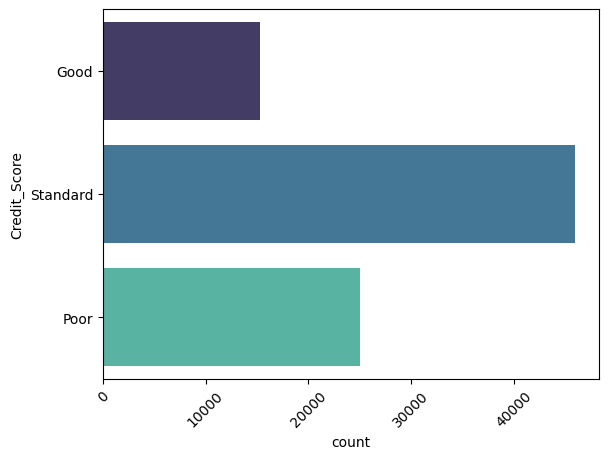

In [13]:
sns.countplot(df_cleaned['Credit_Score'],palette="mako")
plt.xticks(rotation=45)

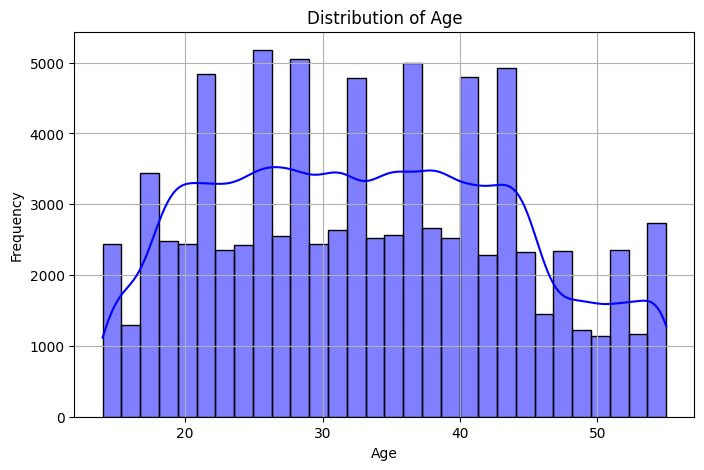

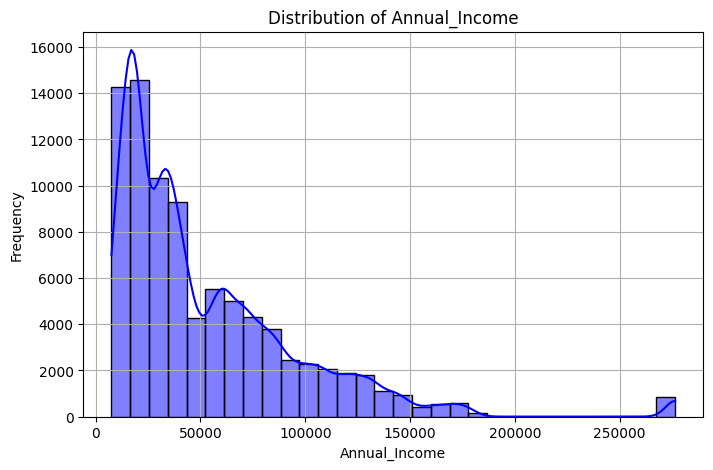

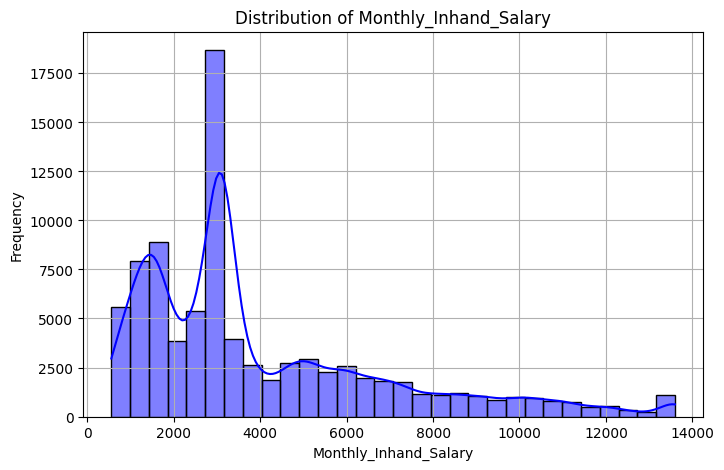

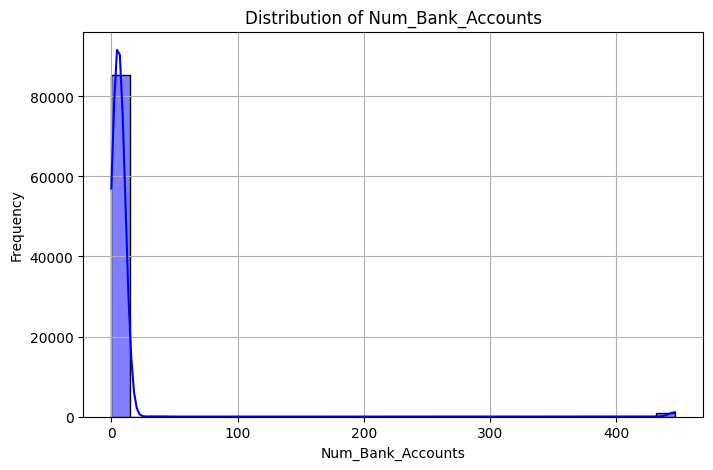

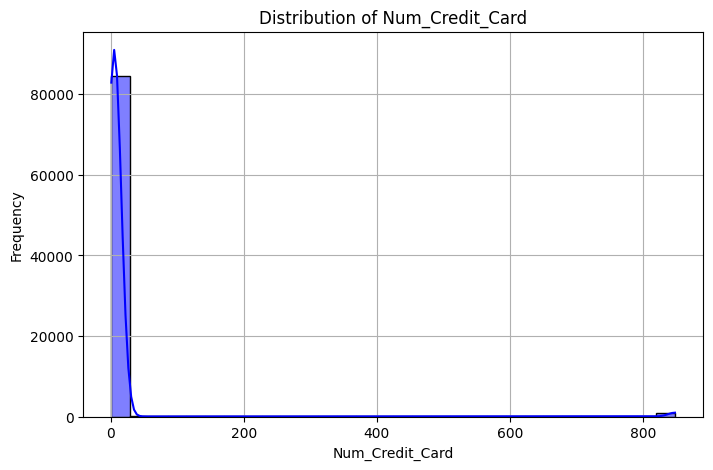

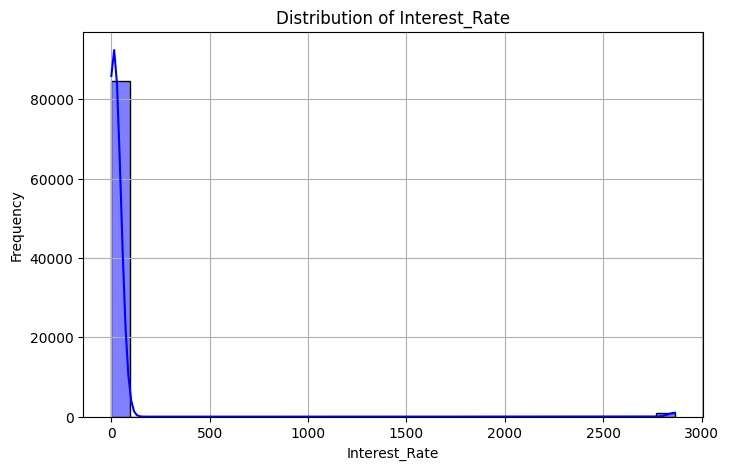

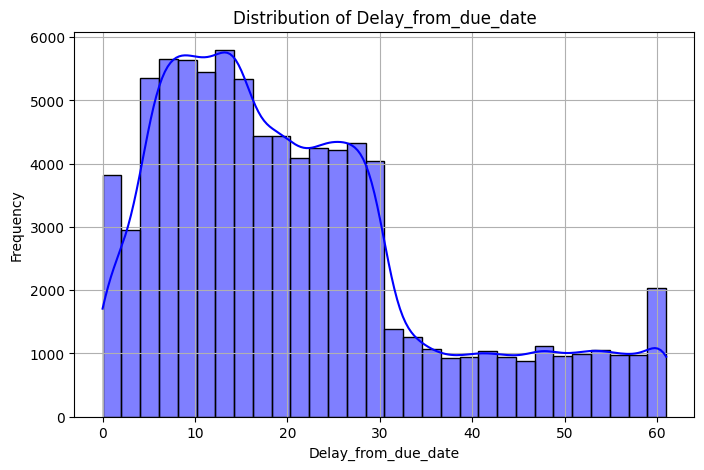

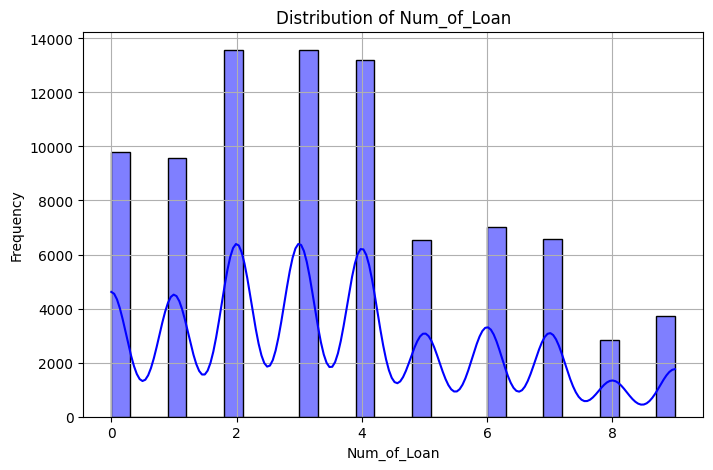

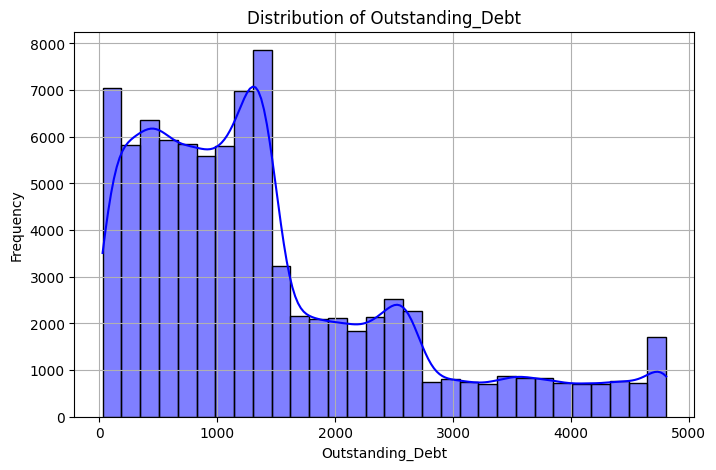

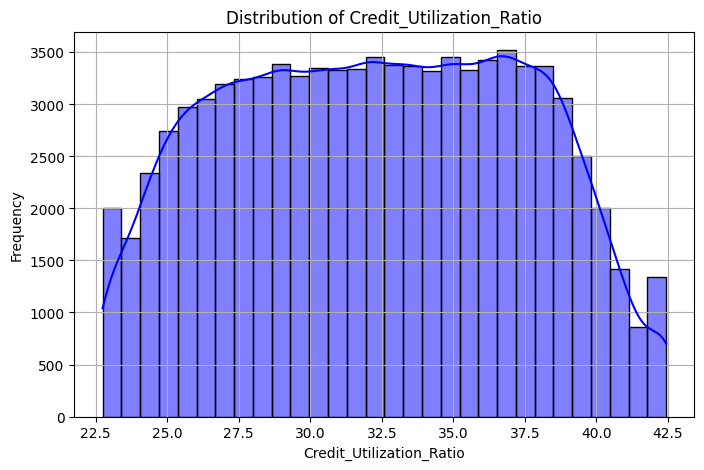

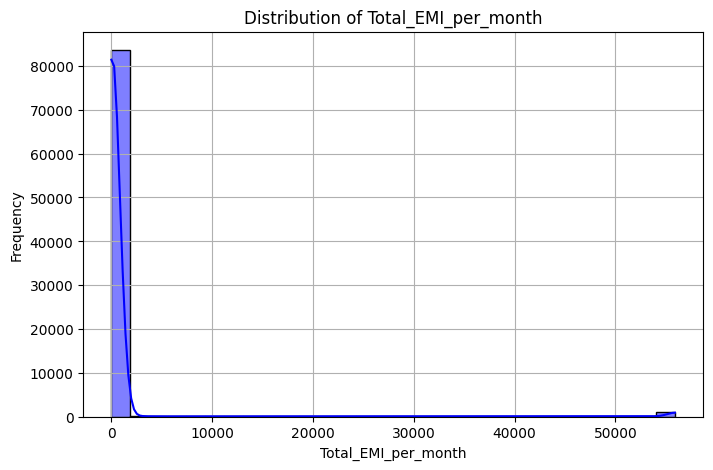

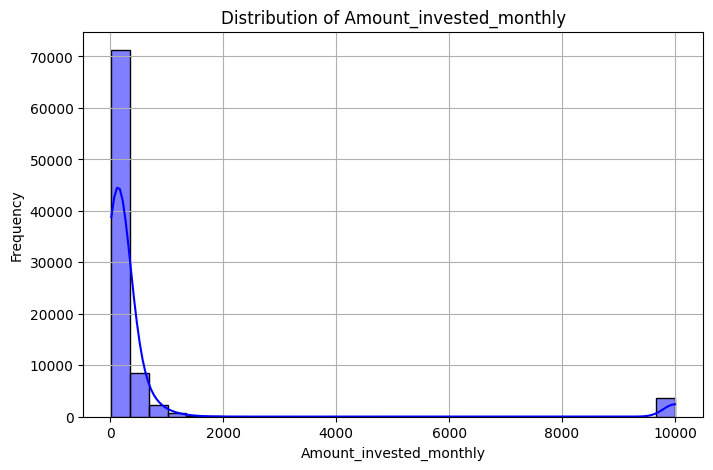

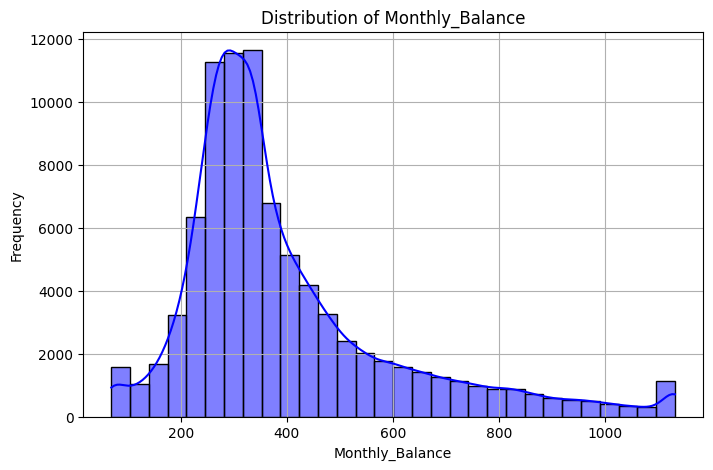

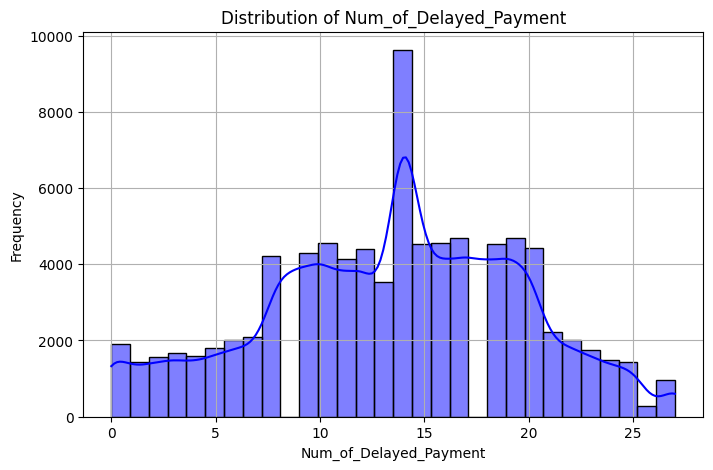

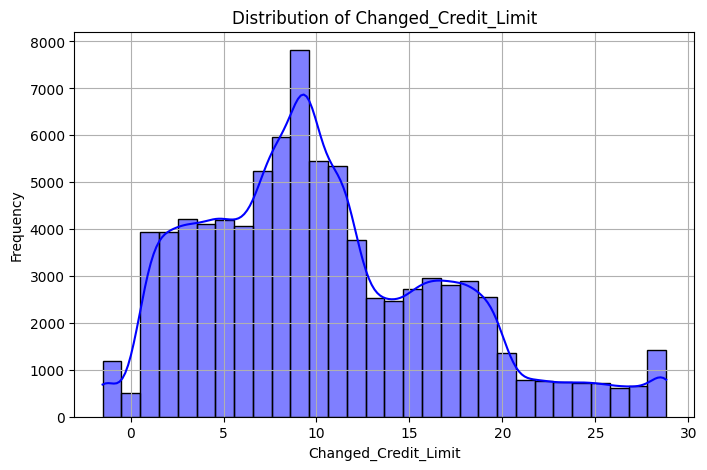

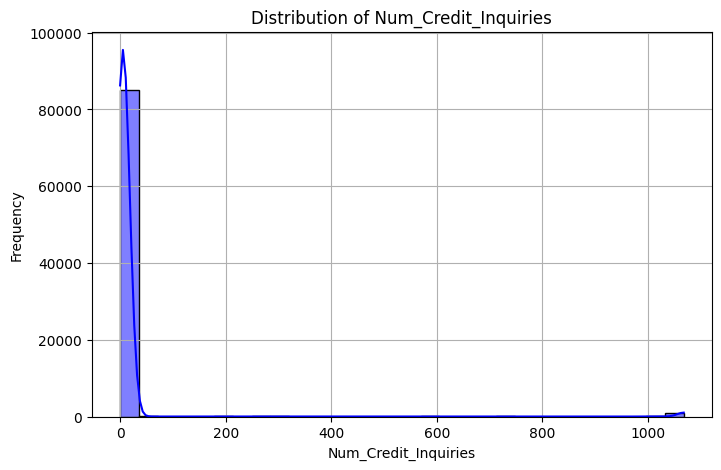

In [14]:
# Set up visualizations
for numerical_column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[numerical_column], kde=True, bins=30, color='blue', edgecolor='black')
    plt.title(f'Distribution of {numerical_column}')
    plt.xlabel(numerical_column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


## 3. Feature Engineering

### 3.1 One-hot Encoding

For the categorical columns, we chose to use one-hot encoding.

In [15]:
df_final = df_cleaned.copy()
df_final.head().T

,0,1,3,4,6
Age,23,23,23,23,23
Occupation,Scientist,Scientist,Scientist,Scientist,Scientist
Annual_Income,19114.12,19114.12,19114.12,19114.12,19114.12
Monthly_Inhand_Salary,1824.843333,3095.905,3095.905,1824.843333,1824.843333
Num_Bank_Accounts,3.0,3.0,3.0,3.0,3.0
Num_Credit_Card,4.0,4.0,4.0,4.0,4.0
Interest_Rate,3.0,3.0,3.0,3.0,3.0
Num_of_Loan,4.0,4.0,4.0,4.0,4.0
Delay_from_due_date,3,0,5,6,3
Num_of_Delayed_Payment,7.0,14.0,4.0,14.0,8.0


In [16]:
df_final['Payment_of_Min_Amount'] = pd.get_dummies(df_final['Payment_of_Min_Amount'], columns=['Payment_of_Min_Amount'],prefix='Payment_of_Min_Amount',dtype=float,drop_first=True)

one_hot_encoding_columns = ['Occupation', 'Payment_Behaviour']
one_hot_encoded_columns = pd.get_dummies(df_final[one_hot_encoding_columns], dtype=float)
df_final = df_final.drop(columns=one_hot_encoding_columns).join(one_hot_encoded_columns)

In [17]:
X = df_final.drop(columns=['Credit_Score'])
X.head().T

,0,1,3,4,6
Age,23.000000,23.000000,23.000000,23.000000,23.000000
Annual_Income,19114.120000,19114.120000,19114.120000,19114.120000,19114.120000
Monthly_Inhand_Salary,1824.843333,3095.905000,3095.905000,1824.843333,1824.843333
Num_Bank_Accounts,3.000000,3.000000,3.000000,3.000000,3.000000
Num_Credit_Card,4.000000,4.000000,4.000000,4.000000,4.000000
Interest_Rate,3.000000,3.000000,3.000000,3.000000,3.000000
Num_of_Loan,4.000000,4.000000,4.000000,4.000000,4.000000
Delay_from_due_date,3.000000,0.000000,5.000000,6.000000,3.000000
Num_of_Delayed_Payment,7.000000,14.000000,4.000000,14.000000,8.000000
Changed_Credit_Limit,11.270000,11.270000,6.270000,11.270000,11.270000


In [27]:
# We use label encoder for our target label
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df_final['Credit_Score'])
y

array([0, 0, 0, ..., 1, 1, 2])

### 3.2 Correlation Matrix

We also generated the correlation matrix for our numerical features. This can help us have a good expectation on the useful features.

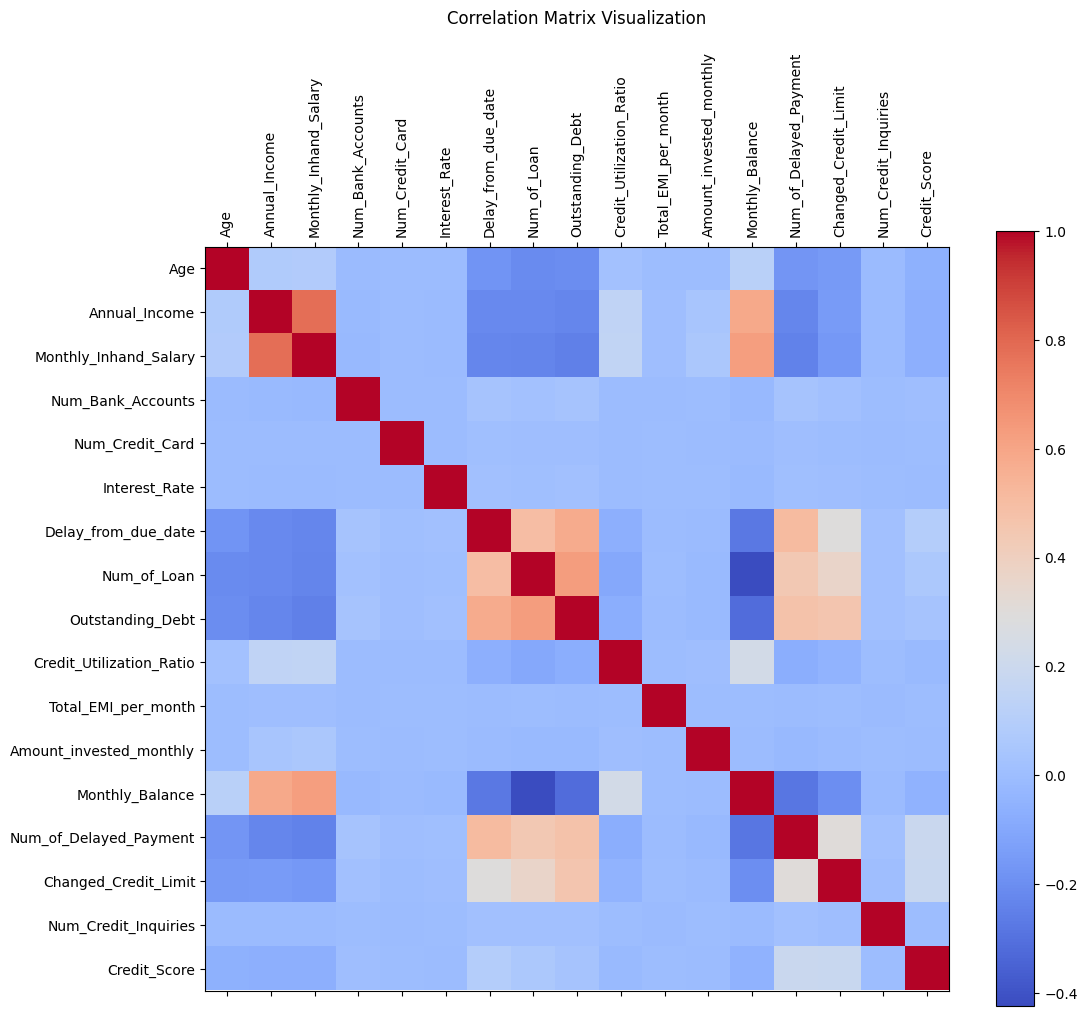

In [19]:
df_final['Credit_Score'] = label_encoder.fit_transform(df_final['Credit_Score'])
correlation_matrix = df_final[numerical_columns+['Credit_Score']].corr()


# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
plt.matshow(correlation_matrix, fignum=1, cmap='coolwarm')

# Adding colorbar and labels
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Adding title
plt.title("Correlation Matrix Visualization", pad=20)
plt.show()


## 4. Machine Learning

### Baseline Models

We have logistic regression, decision tree, xgboost models. We also utilized the grid search algorithm to help find the best parameter combinations. In the end, we used the xgboos model as our best model.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(mse,acc)

0.8647178002894356 0.6071201157742402


In [22]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Accuracy: 0.70 0.6730535455861071


### Improved Models

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
clf = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
}
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {best_params}")

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Accuracy: 0.71 0.6368162083936324


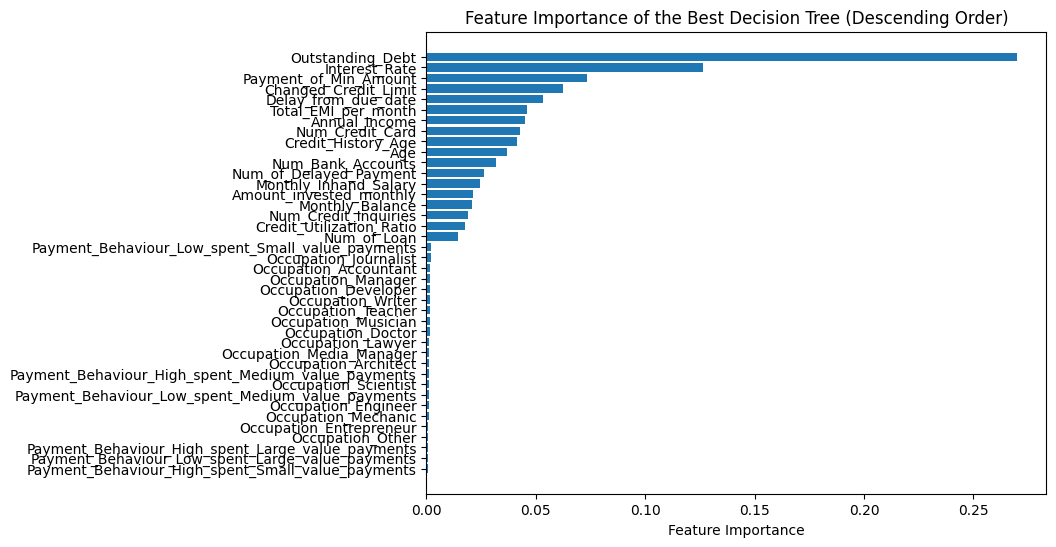

In [24]:
feature_names = df_final.drop(columns=['Credit_Score'], axis=1).columns
feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_feature_names = feature_names[sorted_idx]
sorted_importances = feature_importances[sorted_idx]
plt.figure(figsize=(8, 6))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of the Best Decision Tree (Descending Order)')
plt.gca().invert_yaxis()
plt.show()

In [25]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, 
                           scoring='accuracy', cv=5, verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {best_params}")

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [00:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [00:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [00:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [00:30:09] WARNING: /Users/runner/work/xgboost/xgboost/src

Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.78 0.5025180897250362


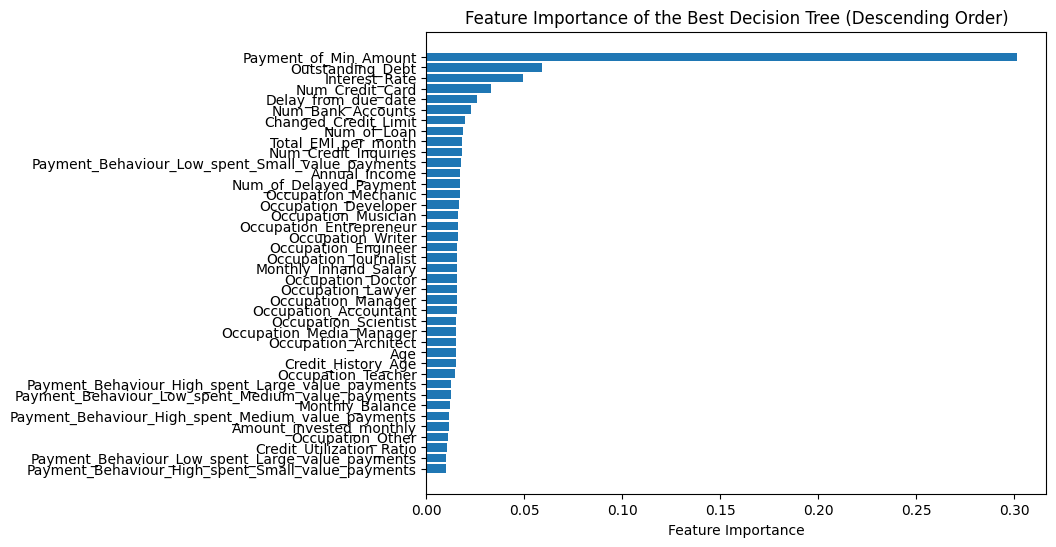

In [26]:
feature_importances = best_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_feature_names = feature_names[sorted_idx]
sorted_importances = feature_importances[sorted_idx]
plt.figure(figsize=(8, 6))
plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
plt.yticks(range(len(sorted_importances)), sorted_feature_names)
plt.xlabel('Feature Importance')
plt.title('Feature Importance of the Best Decision Tree (Descending Order)')
plt.gca().invert_yaxis()
plt.show()